In [2]:
import sys 
sys.path.append("../src")
from data_loader import (load_prices , compute_hedge_ratio,compute_spread, compute_zscore,generate_signals, compute_pnl_with_costs,compute_correlation, find_cointegrated_pairs)

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

prices = load_prices()
print("Prices shape:" , prices.shape)
print("Date range :" , prices.index[0] , "to" , prices.index[-1])

Prices shape: (1509, 41)
Date range : 2018-01-02 00:00:00 to 2023-12-29 00:00:00


In [3]:
formation_months  = 12
trade_months = 1

# generate all windows start dates - monthly frequency 
all_dates = pd.date_range(start = prices.index[0] , end = prices.index[-1],freq = "MS")

windows = []
for i in range(len(all_dates) - formation_months):
    formation_start = all_dates[i]
    formation_end = all_dates[i + formation_months]
    trade_start = all_dates[i + formation_months]

    if trade_start < prices.index[-1]:
        windows.append({
            "formation_start" : formation_start,
            "formation_end" : formation_end,
            "trade_start" : trade_start
        })

print(f"Total windows: {len(windows)}")
print(f"\nFirst windows :")
print(f"  Formation : {windows[0]['formation_start'].date()} to {windows[0]['formation_end'].date()}")
print(f"  Trade on : {windows[0]['trade_start'].date()}")
print(f"\n Last window:")
print(f"  Formation : {windows[-1]['formation_start'].date()} to {windows[-1]['formation_end'].date()}")
print(f"  Trade on : {windows[-1]['trade_start'].date()}")

Total windows: 59

First windows :
  Formation : 2018-02-01 to 2019-02-01
  Trade on : 2019-02-01

 Last window:
  Formation : 2022-12-01 to 2023-12-01
  Trade on : 2023-12-01


In [4]:
# run pair selection on one window manually

# take the first window 
w = windows[0]

# slice prices to formation period only 
formation_prices = prices[(prices.index >= w["formation_start"]) & (prices.index < w["formation_end"])]

print(f"Formation period shape : {formation_prices.shape}")
# run correltion filter
corr_matrix , pairs_df = compute_correlation(formation_prices, threashold=  0.8)
print(f"Correlated pairs found : {len(pairs_df)}")

# run cointegration 
coint_df = find_cointegrated_pairs(formation_prices , pairs_df)
valid_pairs = coint_df[coint_df["cointegrated"] == True]
print(f"Cointegrated pairs found : {len(valid_pairs)}")
print(valid_pairs[["ticker_1","ticker_2","coint_pvalue"]])

Formation period shape : (251, 41)
Correlated pairs found : 72
Cointegrated pairs found : 12
   ticker_1 ticker_2  coint_pvalue
0       AXP     COST      0.001223
1      COST     MSFT      0.003550
2      COST        V      0.007141
3       AXP      UNH      0.008802
4       HON      TGT      0.008853
5      AAPL      TGT      0.014390
6       AXP     MSFT      0.017512
7      MSFT        V      0.029347
8      COST      UNH      0.031751
9       ABT      PFE      0.039652
10       CL      MMM      0.043828
11     AMZN      TGT      0.049896


In [5]:
#build the full rolling window loop

def run_rolling_selection(prices, windows , corr_threshold = 0.8 , coint_threshold = 0.05 , top_n = 5):
    all_results = []
    for i , w in enumerate(windows):

        # slice formation period 
        formation_prices = prices[
            (prices.index >= w["formation_start"]) & 
            (prices.index < w["formation_end"])
        ]

        if len(formation_prices) < 200:
            continue

        try: 
            corr_matrix , pairs_df = compute_correlation(formation_prices , threashold=corr_threshold)

            if len(pairs_df) == 0:
                continue

            coint_df = find_cointegrated_pairs(formation_prices, pairs_df)
            valid = coint_df[coint_df["cointegrated"] == True].head(top_n)

            for _, row in valid.iterrows():
                all_results.append({
                    "window" : i , 
                    "formation_start" : formation_start, 
                    "formation_end" : formation_end,
                    "ticker_1" : row["ticker_1"],
                    "ticker_2" : row["ticker_2"],
                    "coint_pvalue" : row["coint_pvalue"],
                    "correlation" : row["correlation"]
                })

        except Exception as e:
            print(f"Window{i} failed: {e}")
            continue

        if i % 10 == 0:
            print(f"Window {i} / {len(windows)} done - {len(valid)} pairs found")

    return pd.DataFrame(all_results)


print("Starting rolling selection — this will take 2-3 minutes...")
rolling_df = run_rolling_selection(prices, windows)
print(f"\nDone. Total pair-window records: {len(rolling_df)}")
print(f"Unique pairs found across all windows: {rolling_df[['ticker_1','ticker_2']].drop_duplicates().shape[0]}")

Starting rolling selection — this will take 2-3 minutes...
Window 0 / 59 done - 5 pairs found
Window 10 / 59 done - 5 pairs found
Window 20 / 59 done - 5 pairs found
Window 30 / 59 done - 5 pairs found
Window 40 / 59 done - 5 pairs found
Window 50 / 59 done - 5 pairs found

Done. Total pair-window records: 289
Unique pairs found across all windows: 150


In [6]:
# how often does each pair appear across windows
pair_frequency = rolling_df.groupby(["ticker_1","ticker_2"]).size().reset_index(name = "windows_active")
pair_frequency = pair_frequency.sort_values("windows_active" , ascending=False)

print("Most stable pairs(appear in most windows) : ")
print(pair_frequency.head(15))
print(f"Pairs active in 20+ windows : {(pair_frequency['windows_active'] >= 20).sum()}")
print(f"Pairs active in only 1 window : {(pair_frequency['windows_active'] == 1).sum()} ")

Most stable pairs(appear in most windows) : 
    ticker_1 ticker_2  windows_active
34         C       GE               8
37         C      SLB               7
45        CL      KMB               7
53       COP      EOG               7
102      HON     PYPL               5
46        CL       KO               5
120       KO       PG               5
47        CL       MA               4
3       AAPL      PFE               4
101      HON      MMM               4
59      COST       PG               4
83       GIS        V               4
81       GIS       MA               4
77       EOG      XOM               4
17      AMZN     PYPL               4
Pairs active in 20+ windows : 0
Pairs active in only 1 window : 81 


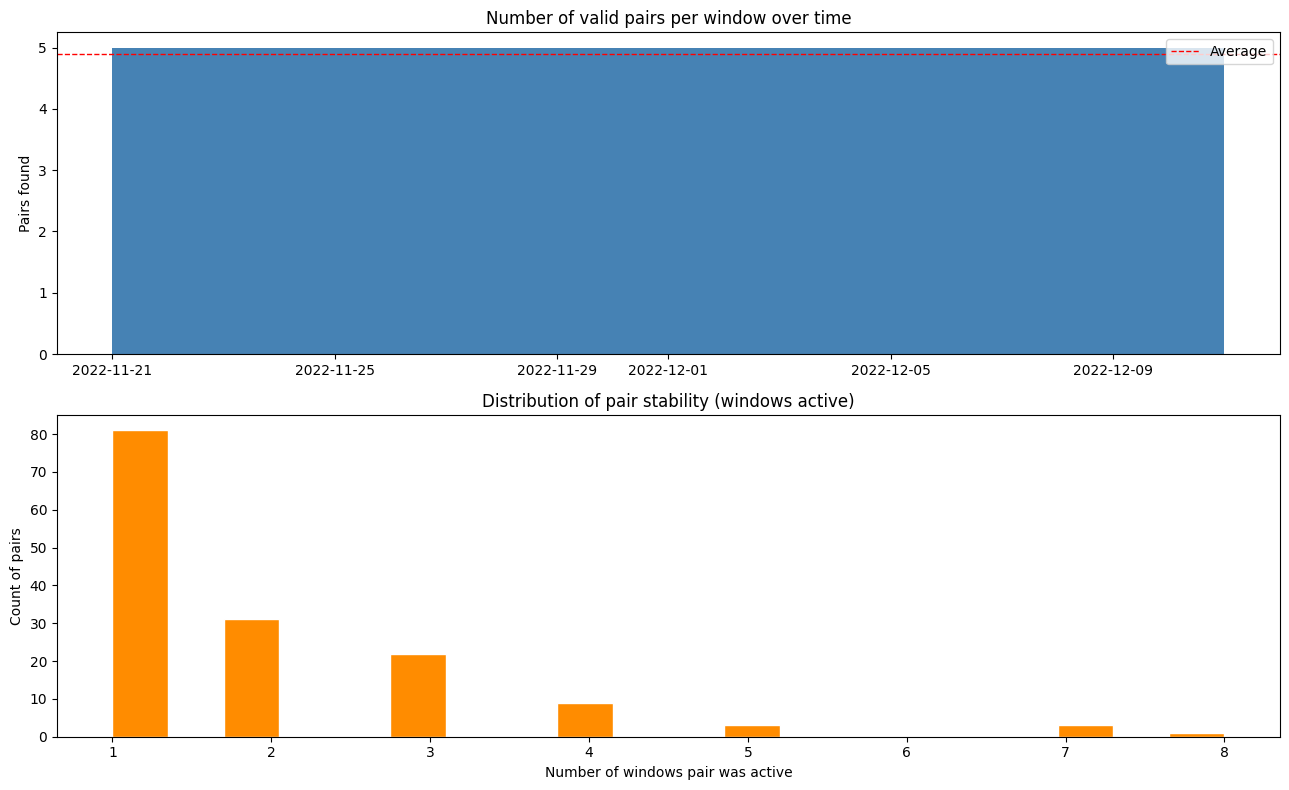

In [13]:
#  visualise pair activity over time

# count how many valid pairs exist per window 
pairs_per_window = rolling_df.groupby("window").size().reset_index(name = "num_pairs")
trade_dates = rolling_df.groupby("window")["formation_start"].first().reset_index()
pairs_per_window = pairs_per_window.merge(trade_dates,on="window")

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# top — pairs per window over time
axes[0].bar(pairs_per_window["formation_start"], 
            pairs_per_window["num_pairs"],
            width=20, color="steelblue", alpha=0.8)
axes[0].set_title("Number of valid pairs per window over time")
axes[0].set_ylabel("Pairs found")
axes[0].axhline(pairs_per_window["num_pairs"].mean(), 
                color="red", linestyle="--", linewidth=1, label="Average")
axes[0].legend()

# bottom — pair frequency distribution
axes[1].hist(pair_frequency["windows_active"], bins=20, 
             color="darkorange", edgecolor="white")
axes[1].set_title("Distribution of pair stability (windows active)")
axes[1].set_xlabel("Number of windows pair was active")
axes[1].set_ylabel("Count of pairs")

plt.tight_layout()
plt.savefig("../data/rolling_selection.png", dpi=120)
plt.show()

In [16]:
rolling_df.to_parquet("../data/rolling_pairs.parquet")
pair_frequency.to_csv("../data/pair_frequency.csv",index= False)

verify = pd.read_parquet("../data/rolling_pairs.parquet")
print("Saved. Shape: ",verify.shape)
print(verify.head(3))

Saved. Shape:  (289, 7)
   window formation_start formation_end ticker_1 ticker_2  coint_pvalue  \
0       0      2022-12-01    2023-12-01      AXP     COST      0.001223   
1       0      2022-12-01    2023-12-01     COST     MSFT      0.003550   
2       0      2022-12-01    2023-12-01     COST        V      0.007141   

   correlation  
0       0.8840  
1       0.9433  
2       0.9356  
